In [17]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.cluster import AgglomerativeClustering

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

from sklearn.datasets import make_blobs

# Data preprocessing

In [7]:
df = pd.read_csv("Wholesale customers data.csv")
df.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB


In [5]:
df.describe()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000
mean,1.322727,2.543182,12000.297727,5796.265909,7951.277273,3071.931818,2881.493182,1524.870455
std,0.468052,0.774272,12647.328865,7380.377175,9503.162829,4854.673333,4767.854448,2820.105937
min,1.000000,1.000000,3.000000,55.000000,3.000000,25.000000,3.000000,3.000000
25%,1.000000,2.000000,3127.750000,1533.000000,2153.000000,742.250000,256.750000,408.250000
50%,1.000000,3.000000,8504.000000,3627.000000,4755.500000,1526.000000,816.500000,965.500000
75%,2.000000,3.000000,16933.750000,7190.250000,10655.750000,3554.250000,3922.000000,1820.250000
max,2.000000,3.000000,112151.000000,73498.000000,92780.000000,60869.000000,40827.000000,47943.000000


In [6]:
df.isnull().sum()

,0
Channel,0
Region,0
Fresh,0
Milk,0
Grocery,0
Frozen,0
Detergents_Paper,0
Delicassen,0


In [7]:
df.duplicated().sum()

np.int64(0)

# K-Mean

In [44]:
X = df[['Grocery', 'Detergents_Paper']]

In [45]:
X_scaled = StandardScaler().fit_transform(X)

In [51]:
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

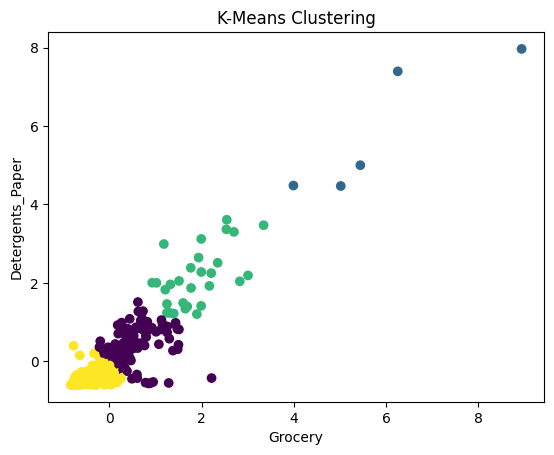

In [52]:
plt.scatter(X_scaled[:, 0],X_scaled[:, 1],c=clusters,cmap='viridis')

plt.xlabel('Grocery')
plt.ylabel('Detergents_Paper')
plt.title('K-Means Clustering')
plt.show()

In [53]:
inertia = []

for k in range(1,11):

    model = KMeans(n_clusters=k)
    model.fit(X_scaled)

    inertia.append(model.inertia_)

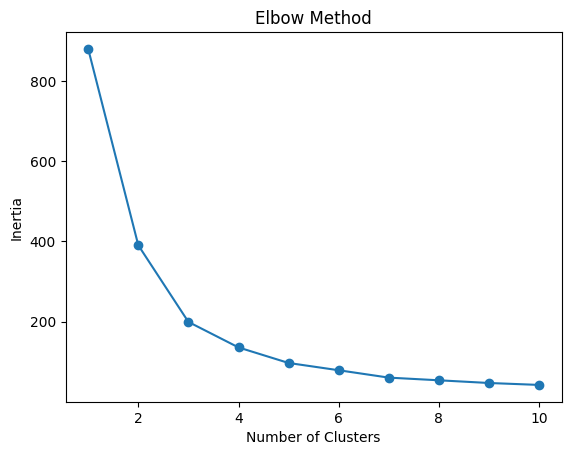

In [54]:
plt.plot(range(1,11), inertia, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()


## K-Means Clustering

- تم اختيار عمودين:
   `Grocery`,`Detergents_Paper`

- تم تطبيق `StandardScaler` لتوحيد مقاييس الأعمدة؛ حتى لا يؤثر العمود ذو القيم الكبيرة على حساب المسافات أكثر من بقية الأعمدة.

- لأن عدد المجموعات المناسب غير معروف من البداية، تم استخدام **Elbow Method** وتجربة قيم مختلفة لـ `K` من 1 إلى 9.

- في كل تجربة تم إنشاء نموذج K-Means بعدد مجموعات مختلف، ثم تدريبه على البيانات بعد الـScaling.

- بعد تدريب كل نموذج تم حساب قيمة `Inertia`، وهي مجموع مربعات المسافات بين كل نقطة والـCentroid الخاص بمجموعتها.

- كلما كانت قيمة `Inertia` أقل، كانت النقاط أقرب إلى مراكز مجموعاتها، لكن لا نختار أقل قيمة مباشرة؛ لأن الـInertia تنخفض طبيعيًا كلما زاد عدد المجموعات.

- تم رسم قيم `Inertia` مقابل قيم `K`، ثم اختيار نقطة الكوع، وهي النقطة التي يبدأ بعدها انخفاض الـInertia يصبح بسيطًا.

- بعد تحديد العدد المناسب للمجموعات، تم تدريب نموذج K-Means النهائي باستخدام قيمة `K` المختارة.

- استخدمنا `fit_predict()` لتدريب النموذج وإعطاء كل عميل رقم المجموعة التي ينتمي إليها.

- تم تمثيل النتائج باستخدام Scatter Plot؛ حيث تمثل كل نقطة عميلًا، وتم استخدام لون مختلف لكل Cluster.

- تم تدريب النموذج باستخدام جميع الأعمدة الستة، لكن الرسم يعرض عمودين فقط؛ لأن Scatter Plot ثنائي الأبعاد.

# Hierarchical Clustering

In [55]:
hc = AgglomerativeClustering(n_clusters=3)
clusters_hc = hc.fit_predict(X_scaled)

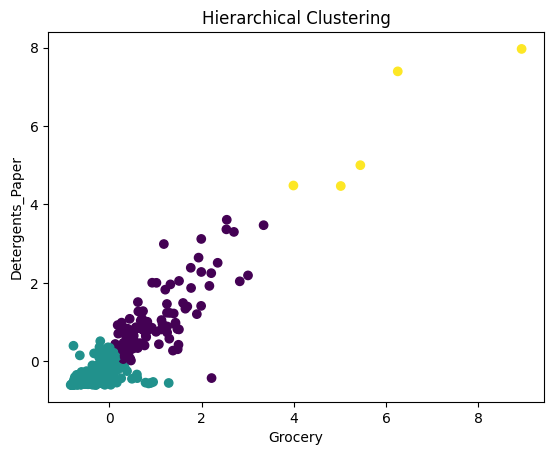

In [57]:
plt.scatter(X_scaled[:, 0],X_scaled[:, 1],c=clusters_hc,cmap='viridis')

plt.xlabel('Grocery')
plt.ylabel('Detergents_Paper')
plt.title('Hierarchical Clustering')
plt.show()

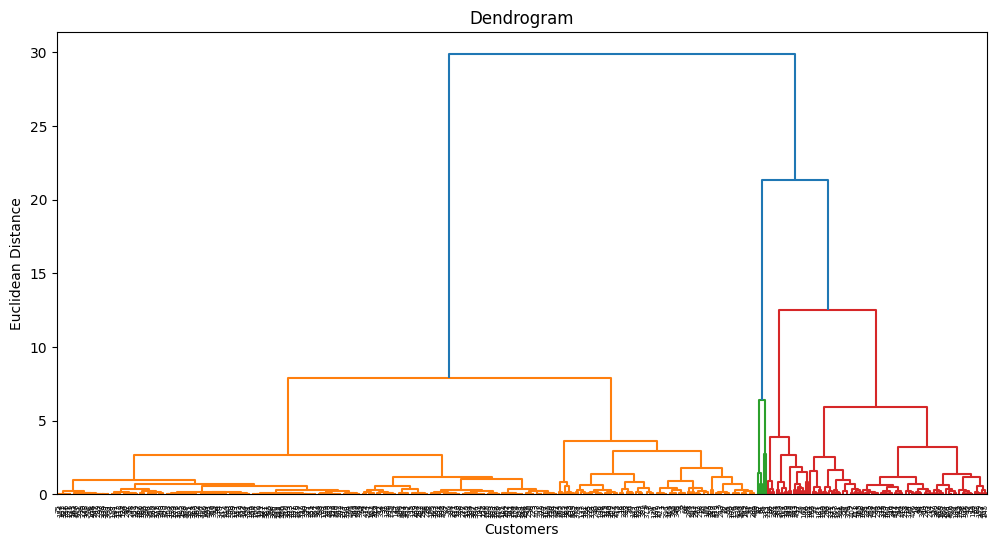

In [58]:
linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(linked)

plt.title("Dendrogram")
plt.xlabel("Customers")
plt.ylabel("Euclidean Distance")
plt.show()

##Hierarchical Clustering

- تم إنشاء نموذج **Hierarchical Clustering** باستخدام خوارزمية `AgglomerativeClustering`.

- تم تحديد عدد المجموعات النهائية باستخدام:
  ```python
  n_clusters = 3
  ```
  أي أن الخوارزمية ستستمر في الدمج حتى تصبح البيانات مقسمة إلى 3 مجموعات.

- تبدأ الخوارزمية باعتبار كل نقطة بيانات **Cluster مستقل**.

- تقوم بحساب المسافات بين جميع النقاط، ثم تدمج أقرب نقطتين معًا.

- بعد كل عملية دمج، تعيد حساب المسافات بين المجموعات الجديدة وتكرر العملية.

- تستمر عملية الدمج تدريجيًا حتى يتبقى العدد المطلوب من المجموعات (3 Clusters).

- استخدمنا:
  ```python
  fit_predict(X_scaled)
  ```
  حيث تقوم `fit` بتدريب الخوارزمية على البيانات، بينما تقوم `predict` بإرجاع رقم الـCluster الذي ينتمي إليه كل عميل.

- تم حفظ نتائج التصنيف داخل المتغير:
  ```python
  clusters_hc
  ```

- كل قيمة داخل `clusters_hc` تمثل رقم المجموعة الخاصة بكل عميل، مثل:
  ```python
  [2, 0, 0, 1, 4, ...]
  ```

- بخلاف **K-Means**، لا تعتمد Hierarchical Clustering على **Centroids**، وإنما تعتمد على دمج أقرب النقاط أو المجموعات تدريجيًا حتى الوصول إلى العدد المطلوب من الـClusters.

# DBSCAN

In [71]:
db = DBSCAN(eps=0.5, min_samples=5)
clusters_db = db.fit_predict(X_scaled)

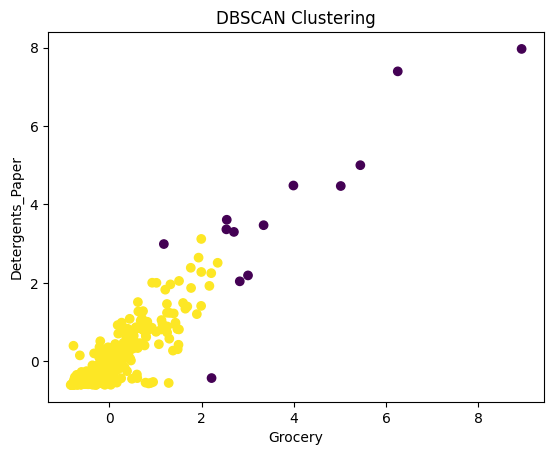

In [72]:
plt.scatter( X_scaled[:, 0], X_scaled[:, 1], c=clusters_db, cmap='viridis')

plt.xlabel('Grocery')
plt.ylabel('Detergents_Paper')
plt.title('DBSCAN Clustering')
plt.show()

In [73]:
print(np.unique(clusters_db))

[-1  0]


## DBSCAN

- تبدأ الخوارزمية باعتبار جميع النقاط غير مصنفة.

- تختار نقطة وتبحث عن جميع النقاط القريبة منها داخل مسافة محددة تسمى `eps`.

- إذا كان عدد النقاط القريبة أكبر من أو يساوي `min_samples`، تعتبر المنطقة ذات كثافة عالية وتبدأ بتكوين **Cluster**.

- تستمر في إضافة جميع النقاط المتصلة بهذه المنطقة حتى يكتمل الـCluster.

- ثم تنتقل إلى نقطة أخرى غير مصنفة وتكرر نفس الخطوات حتى تنتهي من جميع البيانات.

- إذا كانت النقطة لا تمتلك عددًا كافيًا من الجيران داخل `eps`، فإنها لا تُكوّن Cluster وتُصنف على أنها **Noise (Outlier)**.

- لا تحتاج DBSCAN إلى تحديد عدد الـClusters مسبقًا، لأنها تكتشفها تلقائيًا اعتمادًا على كثافة البيانات.

- تعتمد الخوارزمية على قيمتين أساسيتين:
  - `eps`: تحدد المسافة القصوى بين النقاط المتجاورة.
  - `min_samples`: تحدد أقل عدد من النقاط المطلوبة لتكوين Cluster.

In [70]:
# K-Means
kmeans_labels = KMeans(n_clusters=6, random_state=42).fit_predict(X_scaled)
kmeans_score = silhouette_score(X_scaled, kmeans_labels)

# Hierarchical
hc_labels = AgglomerativeClustering(n_clusters=3).fit_predict(X_scaled)
hc_score = silhouette_score(X_scaled, hc_labels)

# DBSCAN
db_labels = DBSCAN(eps=1.0, min_samples=6).fit_predict(X_scaled)

mask = db_labels != -1
if len(np.unique(db_labels[mask])) > 1:
    db_score = silhouette_score(X_scaled[mask], db_labels[mask])
else:
    db_score = -1

print("K-Means:", kmeans_score)
print("Hierarchical:", hc_score)
print("DBSCAN:", db_score)

K-Means: 0.5925689314996064
Hierarchical: 0.6554638529836199
DBSCAN: -1
